# Group Assignment: University of Waterloo Enrolement

### Group 1: 
- Prajapati, Bhavin, b4prajap, bhavin.prajapati@gmail.com
- Herta, Sorin, sherta
- Mathieu, Andrew, amathieu
- Izarra-Jacome, Amaru, aizarraj
- Ho, Anson, a73ho
- Uy, April, a4uy

Group 1 - Project Proposal: https://docs.google.com/document/d/16ejedVsZR0gxWm2Cq63TXL4umfFqIYn5Cb2SG7QoKM0/edit?usp=drive_link

Group 1 - Report: https://docs.google.com/document/d/1-T-YXas5H3eGv0K0VpudtBwtbgvIuvQKme0crm-Ew1Q/edit?usp=drive_link

# Dataset
<a href="https://www.kaggle.com/datasets/chromaa/university-of-waterloo-enrolement" data-toc-modified-id="Bicycle-Thefts-City-of-Toronto-Open-Data-Portal">University of Waterloo Enrolement</a>
<br>
URL: https://www.kaggle.com/datasets/chromaa/university-of-waterloo-enrolement


# Questions
### Who is going to be enrolling in courses?
- Analyze the undergraduate/graduate students and coop/regular.
- Determine students enrolment based on study year (eg. 1st, 2nd, etc)
### What programs are students enrolling into?
- Analyze the diploma/bachelors/masters/doctoral enrolment.
- Assess the different programs and faculties for student enrolment.
### Where are students enrolling?
- Analyze which campus, UW or St. Jerome's University
### When are students enrolling?
- Analyze which study term (eg. Spring, Summer, Fall, Winter)


# Problem
We want to analyze our dataset (waterloo-enrolement-2024.csv) using Apache Spark's MLlib with a given set of paramters which include the following as lists:
- Fiscal Year: 2016/17, 2017/18, ..., 2023/24
- Career: Undergraduate, Graduate
- Study Year: 1, 2, 3, 4, N, D, M
- Program Level: Diploma, Bachelors, Masters, Doctoral
- Faculty: ENG, ARTS, ENV, HEA, MATH, SCI, THL
- Program Grouping: Accounting, Applied Economics, Philosophy, Engineering, etc.
- Campus: University of Waterloo, St. Jerome's University, Conrad Grebel University College
- Term Type: Spring term, Fall term, Winter term, etc.
- Coop Regular: Regular, Coop
- Attendance: Full-Time, Part-Time
- Visa: Canadian, Canadian Permanent Resident, International

The solution should allow configuration of some or all the parameters and use them to train a model to predict student enrolment (Student Headcounts).

## Import Libraries
First we will import all the libraries we need to do our analysis

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum, count, avg, desc
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Create Spark Session

In [2]:
spark = SparkSession.builder \
    .appName('UW Enrolement Prediction') \
    .master('local[*]') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/15 01:21:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Load and Explore the Dataset

In [3]:
df = spark.read.csv('waterloo-enrolement-2024.csv', header=True, inferSchema=True)

# Drop rows with any null values
df = df.dropna()

print(f'Total rows: {df.count()}')
print(f'Total columns: {len(df.columns)}')
print()
df.printSchema()

Total rows: 61273
Total columns: 13

root
 |-- Fiscal Year: string (nullable = true)
 |-- Term Type: string (nullable = true)
 |-- Career: string (nullable = true)
 |-- Program Level: string (nullable = true)
 |-- Study Year: string (nullable = true)
 |-- Campus: string (nullable = true)
 |-- Faculty (group): string (nullable = true)
 |-- Program Grouping: string (nullable = true)
 |-- Coop Regular: string (nullable = true)
 |-- Work Term: string (nullable = true)
 |-- Attendance: string (nullable = true)
 |-- Visa Status: string (nullable = true)
 |-- Student Headcounts: integer (nullable = true)



In [4]:
df.show(10, truncate=False)

+-----------+---------+--------+-------------+----------+----------------------+---------------+-----------------------------+------------+-------------+----------+---------------------------+------------------+
|Fiscal Year|Term Type|Career  |Program Level|Study Year|Campus                |Faculty (group)|Program Grouping             |Coop Regular|Work Term    |Attendance|Visa Status                |Student Headcounts|
+-----------+---------+--------+-------------+----------+----------------------+---------------+-----------------------------+------------+-------------+----------+---------------------------+------------------+
|2016/17    |Fall term|Graduate|Diploma      |N         |University of Waterloo|ENG            |Business and Entrepreneurship|Regular     |Academic Term|Part-Time |Canadian Permanent Resident|1                 |
|2016/17    |Fall term|Graduate|Diploma      |N         |University of Waterloo|ENG            |Business and Entrepreneurship|Regular     |Academic Term

In [5]:
# Summary statistics for the target variable
df.select('Student Headcounts').describe().show()

+-------+------------------+
|summary|Student Headcounts|
+-------+------------------+
|  count|             61273|
|   mean|13.955869632627747|
| stddev|30.197646865536903|
|    min|                 1|
|    max|               552|
+-------+------------------+



## Exploratory Data Analysis
Explore the distinct values for each categorical column.

In [6]:
# Distinct values per column
for c in df.columns:
    distinct_count = df.select(c).distinct().count()
    print(f'{c}: {distinct_count} distinct values')

Fiscal Year: 8 distinct values


Term Type: 3 distinct values


Career: 2 distinct values


Program Level: 6 distinct values


Study Year: 8 distinct values


...

Coop Regular: 2 distinct values


Work Term: 2 distinct values


Attendance: 3 distinct values


Visa Status: 3 distinct values


Student Headcounts: 337 distinct values


In [7]:
# Enrolment by Career (Undergraduate vs Graduate)
career_df = df.groupBy('Career').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts'),
    count('*').alias('Record Count')
).orderBy(desc('Total Headcounts'))
career_df.show()

+-------------+----------------+------------+
|       Career|Total Headcounts|Record Count|
+-------------+----------------+------------+
|Undergraduate|          716370|       50015|
|     Graduate|          138748|       11258|
+-------------+----------------+------------+



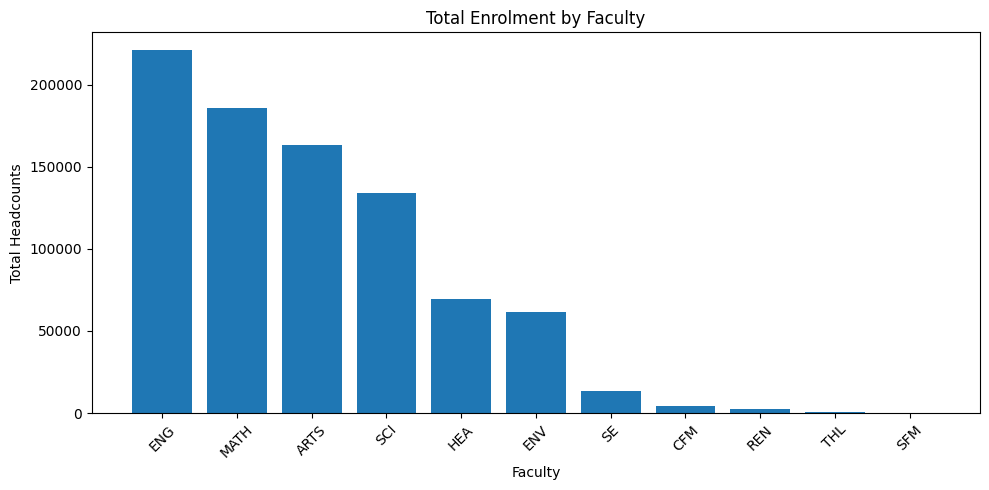

In [8]:
# Enrolment by Faculty
faculty_df = df.groupBy('Faculty (group)').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts')
).orderBy(desc('Total Headcounts'))

faculty_pd = faculty_df.toPandas().dropna(subset=['Faculty (group)'])
plt.figure(figsize=(10, 5))
plt.bar(faculty_pd['Faculty (group)'].astype(str), faculty_pd['Total Headcounts'])
plt.xlabel('Faculty')
plt.ylabel('Total Headcounts')
plt.title('Total Enrolment by Faculty')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Enrolment by Term Type
term_df = df.groupBy('Term Type').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts')
).orderBy(desc('Total Headcounts'))
term_df.show()

+-----------+----------------+
|  Term Type|Total Headcounts|
+-----------+----------------+
|  Fall term|          325000|
|Winter term|          312894|
|Spring term|          217224|
+-----------+----------------+



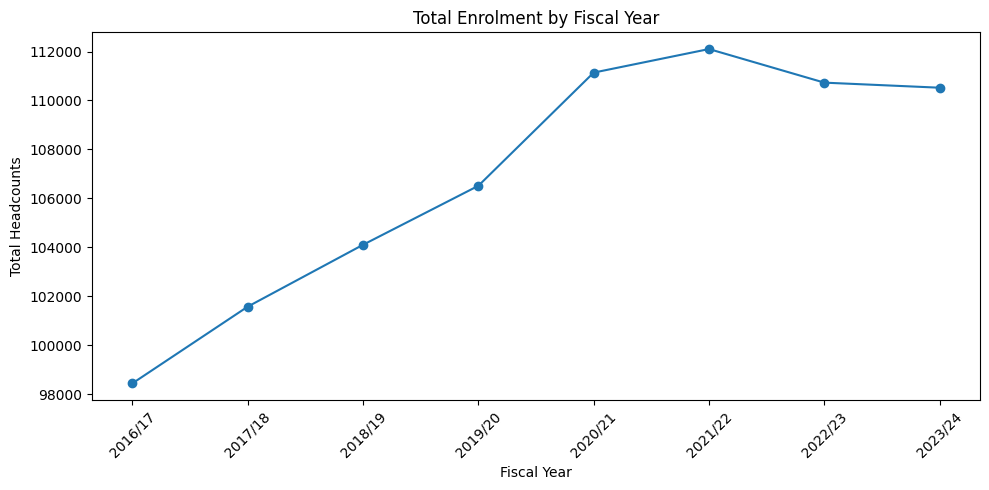

In [10]:
# Enrolment by Fiscal Year
year_df = df.groupBy('Fiscal Year').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts')
).orderBy('Fiscal Year')

year_pd = year_df.toPandas().dropna(subset=['Fiscal Year'])
plt.figure(figsize=(10, 5))
plt.plot(year_pd['Fiscal Year'].astype(str), year_pd['Total Headcounts'], marker='o')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Headcounts')
plt.title('Total Enrolment by Fiscal Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Enrolment by Coop vs Regular
coop_df = df.groupBy('Coop Regular').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts')
).orderBy(desc('Total Headcounts'))
coop_df.show()

+------------+----------------+
|Coop Regular|Total Headcounts|
+------------+----------------+
|       Co-op|          517106|
|     Regular|          338012|
+------------+----------------+



In [12]:
# Enrolment by Campus
campus_df = df.groupBy('Campus').agg(
    spark_sum('Student Headcounts').alias('Total Headcounts')
).orderBy(desc('Total Headcounts'))
campus_df.show(truncate=False)

+--------------------------------+----------------+
|Campus                          |Total Headcounts|
+--------------------------------+----------------+
|University of Waterloo          |831903          |
|Renison University College      |12168           |
|St. Jerome's University         |10171           |
|Conrad Grebel University College|629             |
|Online - Renison                |168             |
|Online                          |79              |
+--------------------------------+----------------+



## Configurable Parameters
Configure which parameter values to include when training the model. Set any parameter to `None` to include all values, or provide a list to filter to specific values.

In [13]:
# ====================================================================
# CONFIGURABLE PARAMETERS
# Set any parameter to None to include ALL values for that column.
# Otherwise, provide a list of values to filter on.
# ====================================================================

config = {
    'Fiscal Year':       None,  # e.g. ['2022/23', '2023/24']
    'Career':            None,  # e.g. ['Undergraduate']
    'Study Year':        None,  # e.g. ['1', '2', '3', '4']
    'Program Level':     None,  # e.g. ['Bachelors', 'Masters']
    'Faculty (group)':   None,  # e.g. ['ENG', 'MATH']
    'Program Grouping':  None,  # e.g. ['Computer Science', 'Engineering']
    'Campus':            None,  # e.g. ['University of Waterloo']
    'Term Type':         None,  # e.g. ['Fall term', 'Winter term']
    'Coop Regular':      None,  # e.g. ['Coop']
    'Attendance':        None,  # e.g. ['Full-Time']
    'Visa Status':       None,  # e.g. ['Canadian', 'International']
}

# Apply filters based on configuration
filtered_df = df
for col_name, values in config.items():
    if values is not None:
        filtered_df = filtered_df.filter(col(col_name).isin(values))

print(f'Rows after filtering: {filtered_df.count()} (out of {df.count()})')

Rows after filtering: 61273 (out of 61273)


## Data Preprocessing
Encode all categorical features using StringIndexer and OneHotEncoder, then assemble them into a feature vector.

In [14]:
# Define categorical feature columns (all columns except the target)
categorical_cols = [c for c in filtered_df.columns if c != 'Student Headcounts']

# Drop rows with null target
filtered_df = filtered_df.dropna(subset=['Student Headcounts'])

# Build StringIndexer and OneHotEncoder stages for each categorical column
indexers = []
encoders = []
encoded_cols = []

for c in categorical_cols:
    idx_col = c + '_idx'
    ohe_col = c + '_ohe'
    indexers.append(StringIndexer(inputCol=c, outputCol=idx_col, handleInvalid='keep'))
    encoders.append(OneHotEncoder(inputCol=idx_col, outputCol=ohe_col))
    encoded_cols.append(ohe_col)

# Assemble all encoded features into a single vector
assembler = VectorAssembler(inputCols=encoded_cols, outputCol='features')

print(f'Categorical columns: {categorical_cols}')
print(f'Number of feature columns: {len(categorical_cols)}')

Categorical columns: ['Fiscal Year', 'Term Type', 'Career', 'Program Level', 'Study Year', 'Campus', 'Faculty (group)', 'Program Grouping', 'Coop Regular', 'Work Term', 'Attendance', 'Visa Status']
Number of feature columns: 12


## Train/Test Split

In [15]:
# Rename target column to 'label' for MLlib
model_df = filtered_df.withColumnRenamed('Student Headcounts', 'label')

# Split data: 80% train, 20% test
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print(f'Training set size: {train_df.count()}')
print(f'Test set size: {test_df.count()}')

Training set size: 49191


Test set size: 12082


## Model Training
We train three regression models using MLlib and compare their performance:
1. **Linear Regression**
2. **Random Forest Regressor**
3. **Gradient-Boosted Tree Regressor**

In [16]:
# Define models with tuned hyperparameters
lr = LinearRegression(featuresCol='features', labelCol='label', maxIter=100, regParam=0.01, elasticNetParam=0.5)
rf = RandomForestRegressor(featuresCol='features', labelCol='label', numTrees=200, maxDepth=12, minInstancesPerNode=2, featureSubsetStrategy='sqrt', seed=42)
gbt = GBTRegressor(featuresCol='features', labelCol='label', maxIter=200, maxDepth=8, stepSize=0.05, subsamplingRate=0.8, seed=42)

models = {
    'Linear Regression': lr,
    'Random Forest': rf,
    'Gradient-Boosted Trees': gbt,
}

# Build pipeline stages (shared across models)
preprocessing_stages = indexers + encoders + [assembler]

# Train and evaluate each model
results = {}
trained_models = {}

evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
evaluator_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')
evaluator_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')

for name, model in models.items():
    print(f'Training {name}...')
    pipeline = Pipeline(stages=preprocessing_stages + [model])
    pipeline_model = pipeline.fit(train_df)
    predictions = pipeline_model.transform(test_df)
    
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    
    results[name] = {'RMSE': rmse, 'R2': r2, 'MAE': mae}
    trained_models[name] = pipeline_model
    
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print()

Training Linear Regression...


  RMSE: 26.4261
  R²:   0.3038
  MAE:  14.4443

Training Random Forest...


  RMSE: 24.4197
  R²:   0.4055
  MAE:  11.6459

Training Gradient-Boosted Trees...


  RMSE: 12.6633
  R²:   0.8401
  MAE:  5.8615



## Model Comparison

                             RMSE        R2        MAE
Model                                                 
Linear Regression       26.426148  0.303795  14.444330
Random Forest           24.419712  0.405502  11.645939
Gradient-Boosted Trees  12.663288  0.840132   5.861525


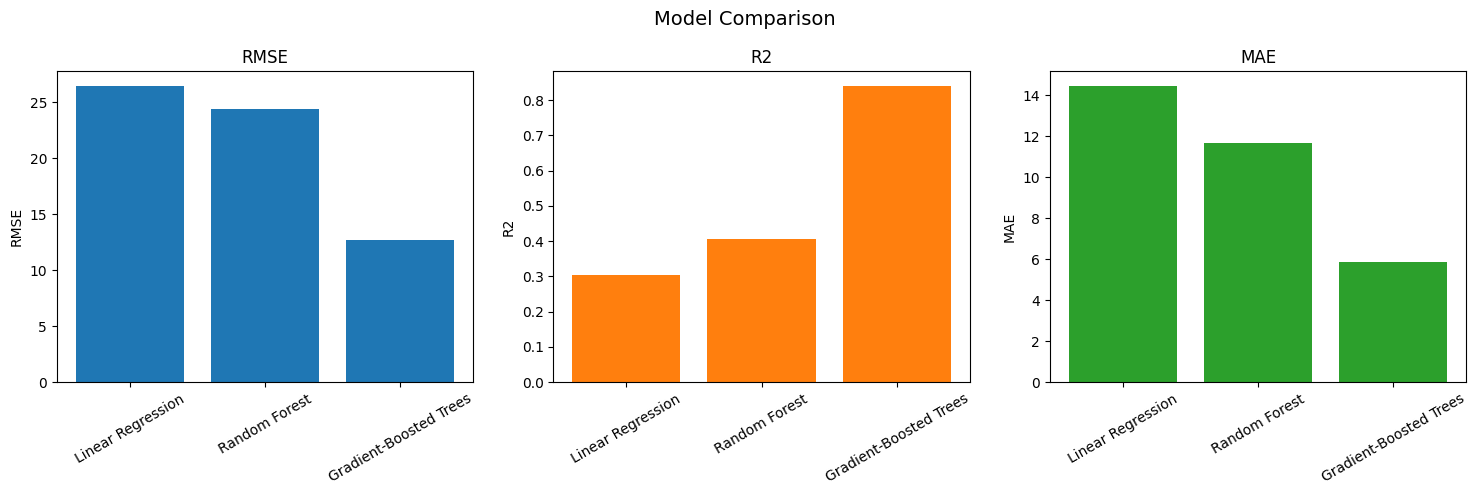

In [17]:
# Compare models side by side
results_pd = pd.DataFrame(results).T
results_pd.index.name = 'Model'
print(results_pd.to_string())

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'R2', 'MAE']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, metric in enumerate(metrics):
    axes[i].bar(results_pd.index, results_pd[metric], color=colors[i])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Best Model - Predictions vs Actuals
Select the best model based on R² and visualize its predictions.

In [18]:
# Select best model by R²
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_model = trained_models[best_model_name]

print(f'Best model: {best_model_name}')
print(f'  R²:   {results[best_model_name]["R2"]:.4f}')
print(f'  RMSE: {results[best_model_name]["RMSE"]:.4f}')
print(f'  MAE:  {results[best_model_name]["MAE"]:.4f}')

Best model: Gradient-Boosted Trees
  R²:   0.8401
  RMSE: 12.6633
  MAE:  5.8615


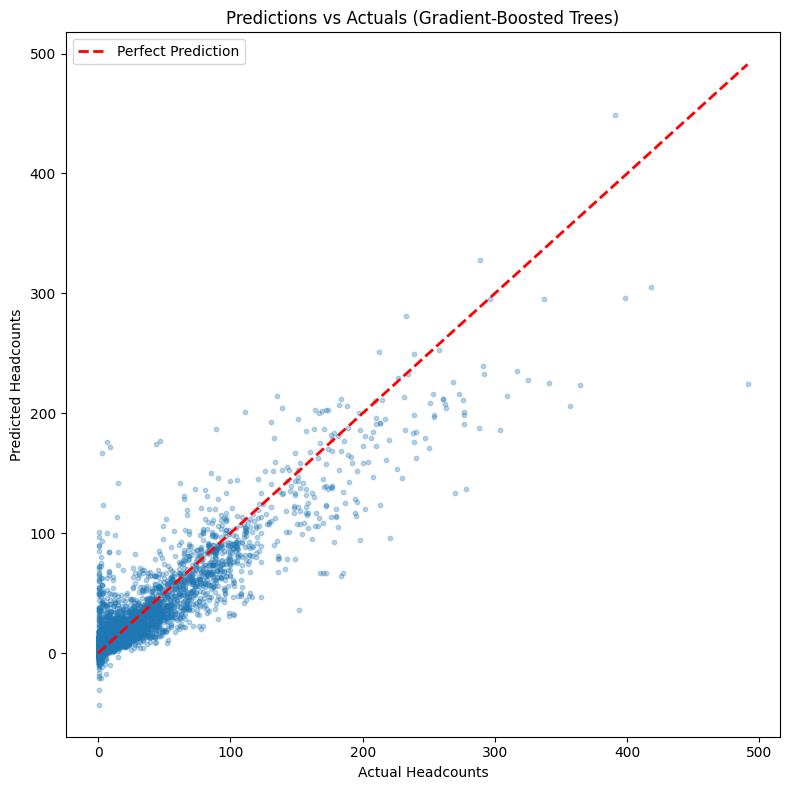

In [19]:
# Predictions vs Actuals scatter plot
best_predictions = best_model.transform(test_df)
pred_pd = best_predictions.select('label', 'prediction').toPandas()

plt.figure(figsize=(8, 8))
plt.scatter(pred_pd['label'], pred_pd['prediction'], alpha=0.3, s=10)

# Perfect prediction line
max_val = max(pred_pd['label'].max(), pred_pd['prediction'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Headcounts')
plt.ylabel('Predicted Headcounts')
plt.title(f'Predictions vs Actuals ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance
Display feature importance for the Random Forest model.

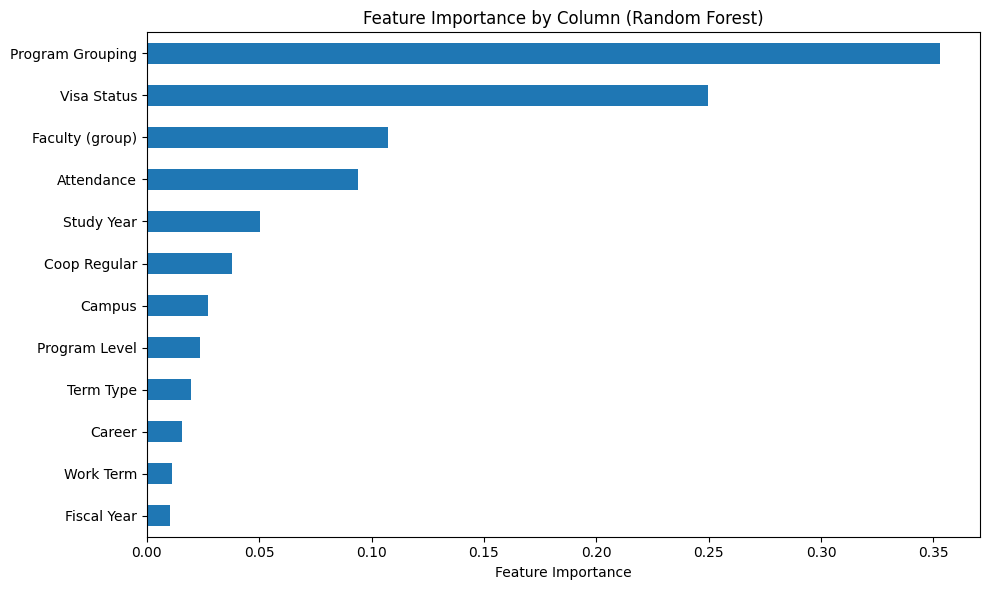

In [20]:
# Get feature importance from the Random Forest model
rf_pipeline = trained_models['Random Forest']
rf_model = rf_pipeline.stages[-1]  # Last stage is the model

# Get feature names from the assembler metadata
assembler_stage = rf_pipeline.stages[-2]  # VectorAssembler

# Map importance to encoded column groups
importances = rf_model.featureImportances.toArray()

# Aggregate importance by original categorical column
# Each OHE column group corresponds to one original categorical column
col_importance = {}
idx = 0
for i, c in enumerate(categorical_cols):
    # Get the OneHotEncoder output size from the trained model
    ohe_model = rf_pipeline.stages[len(categorical_cols) + i]  # encoder stage
    size = ohe_model.categorySizes[0] - 1  # OHE drops last category
    col_importance[c] = sum(importances[idx:idx+size])
    idx += size

# Sort and plot
imp_pd = pd.Series(col_importance).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
imp_pd.plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Feature Importance by Column (Random Forest)')
plt.tight_layout()
plt.show()

## Answering the Research Questions

In [21]:
# Q1: Who is enrolling? - Undergraduate vs Graduate, Coop vs Regular, by Study Year
print('=== Q1: Who is going to be enrolling? ===')
print()
print('By Career:')
df.groupBy('Career').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

print('By Coop/Regular:')
df.groupBy('Coop Regular').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

print('By Study Year:')
df.groupBy('Study Year').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

=== Q1: Who is going to be enrolling? ===

By Career:


+-------------+------+
|       Career| Total|
+-------------+------+
|Undergraduate|716370|
|     Graduate|138748|
+-------------+------+

By Coop/Regular:


+------------+------+
|Coop Regular| Total|
+------------+------+
|       Co-op|517106|
|     Regular|338012|
+------------+------+

By Study Year:


+----------+------+
|Study Year| Total|
+----------+------+
|         2|193062|
|         3|189520|
|         4|171875|
|         1|143101|
|         M| 87417|
|         D| 50577|
|         N| 18316|
|         5|  1250|
+----------+------+



In [22]:
# Q2: What programs are students enrolling into?
print('=== Q2: What programs are students enrolling into? ===')
print()
print('By Program Level:')
df.groupBy('Program Level').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

print('By Faculty:')
df.groupBy('Faculty (group)').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

print('Top 15 Program Groupings:')
df.groupBy('Program Grouping').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show(15, truncate=False)

=== Q2: What programs are students enrolling into? ===

By Program Level:


+-------------+------+
|Program Level| Total|
+-------------+------+
|    Bachelors|698814|
|      Masters| 86833|
|     Doctoral| 51160|
|   Non-Degree| 17587|
|      Diploma|   689|
|   Qualifying|    35|
+-------------+------+

By Faculty:


+---------------+------+
|Faculty (group)| Total|
+---------------+------+
|            ENG|220782|
|           MATH|185643|
|           ARTS|163011|
|            SCI|133746|
|            HEA| 69338|
|            ENV| 61568|
|             SE| 13546|
|            CFM|  4171|
|            REN|  2294|
|            THL|   726|
|            SFM|   293|
+---------------+------+

Top 15 Program Groupings:


+-----------------------------------+-----+
|Program Grouping                   |Total|
+-----------------------------------+-----+
|Computer Science                   |69807|
|Mathematics                        |34856|
|Accounting and Financial Management|34021|
|Mechanical Engineering             |31554|
|Computer Engineering               |29980|
|Science                            |25063|
|Arts                               |24554|
|Kinesiology                        |22827|
|Mechatronics Engineering           |22585|
|Psychology                         |19515|
|Chemical Engineering               |18763|
|Civil Engineering                  |18530|
|Health Studies                     |15249|
|Systems Design Engineering         |14980|
|Biology                            |14957|
+-----------------------------------+-----+
only showing top 15 rows


In [23]:
# Q3: Where are students enrolling?
print('=== Q3: Where are students enrolling? ===')
print()
df.groupBy('Campus').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show(truncate=False)

=== Q3: Where are students enrolling? ===



+--------------------------------+------+
|Campus                          |Total |
+--------------------------------+------+
|University of Waterloo          |831903|
|Renison University College      |12168 |
|St. Jerome's University         |10171 |
|Conrad Grebel University College|629   |
|Online - Renison                |168   |
|Online                          |79    |
+--------------------------------+------+



In [24]:
# Q4: When are students enrolling?
print('=== Q4: When are students enrolling? ===')
print()
print('By Term Type:')
df.groupBy('Term Type').agg(spark_sum('Student Headcounts').alias('Total')).orderBy(desc('Total')).show()

print('By Fiscal Year and Term:')
df.groupBy('Fiscal Year', 'Term Type').agg(
    spark_sum('Student Headcounts').alias('Total')
).orderBy('Fiscal Year', 'Term Type').show(30, truncate=False)

=== Q4: When are students enrolling? ===

By Term Type:


+-----------+------+
|  Term Type| Total|
+-----------+------+
|  Fall term|325000|
|Winter term|312894|
|Spring term|217224|
+-----------+------+

By Fiscal Year and Term:


+-----------+-----------+-----+
|Fiscal Year|Term Type  |Total|
+-----------+-----------+-----+
|2016/17    |Fall term  |37732|
|2016/17    |Spring term|24418|
|2016/17    |Winter term|36288|
|2017/18    |Fall term  |38894|
|2017/18    |Spring term|25114|
|2017/18    |Winter term|37565|
|2018/19    |Fall term  |39791|
|2018/19    |Spring term|25851|
|2018/19    |Winter term|38460|
|2019/20    |Fall term  |40709|
|2019/20    |Spring term|26536|
|2019/20    |Winter term|39268|
|2020/21    |Fall term  |42065|
|2020/21    |Spring term|28522|
|2020/21    |Winter term|40552|
|2021/22    |Fall term  |42309|
|2021/22    |Spring term|29505|
|2021/22    |Winter term|40288|
|2022/23    |Fall term  |41800|
|2022/23    |Spring term|28672|
|2022/23    |Winter term|40257|
|2023/24    |Fall term  |41700|
|2023/24    |Spring term|28606|
|2023/24    |Winter term|40216|
+-----------+-----------+-----+



## Cleanup

In [25]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.
